# Shadow P&L — Notebook 01: Foundation
## Acts 1 + 2 · DATATHON 2026 · Gridbreaker Team

**Story arc:**
- **Act 1 — The Illusion:** Top-line looks healthy. Let's believe the surface numbers.
- **Act 2 — The Unmasking:** Peel back every layer. How much of that revenue actually survives?

**Rules in force:** DuckDB-first · All VND via `format_vnd()` · No hardcoded numbers in markdown · MCQ definitions exact

In [1]:
# Cell 2: Imports and style setup
import sys
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve()))

import duckdb
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import numpy as np
import pandas as pd

from shadow_pnl_style import (
    apply_shadow_pnl_style,
    SHADOW_PNL_COLORS,
    LEAK_ORDER,
    format_vnd,
    format_pct,
    vnd_impact,
    init_audit_log,
    finalize_chart,
 )

apply_shadow_pnl_style()
init_audit_log(Path('../outputs_round1/shadow_pnl_audit.csv'))

CHARTS_DIR = Path('../outputs_round1/charts')
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

print('Style loaded. Audit log initialised.')

Style loaded. Audit log initialised.


In [2]:
# ── Cell 1: DuckDB ingest ─────────────────────────────────────────────────
from gridbreaker_ops.warehouse import ingest_csvs

con = duckdb.connect()
ingest_log = ingest_csvs(con, Path('../Data'))

total_rows = sum(r['row_count'] for r in ingest_log)
print(f'Ingested {len(ingest_log)} tables · {total_rows:,} total rows')
for r in ingest_log:
    print(f"  {r['table_name']:<20} {r['row_count']:>8,} rows")

Ingested 14 tables · 2,960,736 total rows
  customers             121,930 rows
  geography              39,948 rows
  inventory              60,247 rows
  order_items           714,669 rows
  orders                646,945 rows
  payments              646,945 rows
  products                2,412 rows
  promotions                 50 rows
  returns                39,939 rows
  reviews               113,551 rows
  sales                   3,833 rows
  sample_submission         548 rows
  shipments             566,067 rows
  web_traffic             3,652 rows


---
# ACT 1 — THE ILLUSION
> *Nhìn vào 10 năm dữ liệu, top-line của business này trông thế nào nếu chỉ tin báo cáo bề mặt?*

In [3]:
# ── Act 1 SQL: Annual revenue from sales spine ────────────────────────────
annual_revenue = con.execute("""
    SELECT
        EXTRACT(year FROM Date)::INT AS year,
        SUM(Revenue)                  AS gross_revenue,
        SUM(COGS)                     AS total_cogs
    FROM sales
    GROUP BY year
    ORDER BY year
""").df()

annual_orders = con.execute("""
    SELECT
        EXTRACT(year FROM order_date)::INT AS year,
        COUNT(*)                            AS total_orders,
        COUNT(DISTINCT customer_id)         AS unique_customers
    FROM orders
    GROUP BY year
    ORDER BY year
""").df()

aov_row = con.execute("""
    SELECT MEDIAN(item_total) AS aov_median
    FROM (
        SELECT o.order_id, SUM(oi.quantity * oi.unit_price) AS item_total
        FROM orders o
        JOIN order_items oi ON o.order_id = oi.order_id
        GROUP BY o.order_id
    )
""").df()

# Key scalars
gross_total_10y    = annual_revenue['gross_revenue'].sum()
total_orders_10y   = annual_orders['total_orders'].sum()
unique_cust_10y    = con.execute("SELECT COUNT(DISTINCT customer_id) FROM orders").fetchone()[0]
aov_median_vnd     = aov_row['aov_median'].iloc[0]

print(f"Gross revenue 10Y : {format_vnd(gross_total_10y)}")
print(f"Total orders  10Y : {total_orders_10y:,}")
print(f"Unique customers  : {unique_cust_10y:,}")
print(f"Median order value: {format_vnd(aov_median_vnd)}")

Gross revenue 10Y : 16.43 tỷ VND
Total orders  10Y : 646,945
Unique customers  : 90,246
Median order value: 18.3 nghìn VND


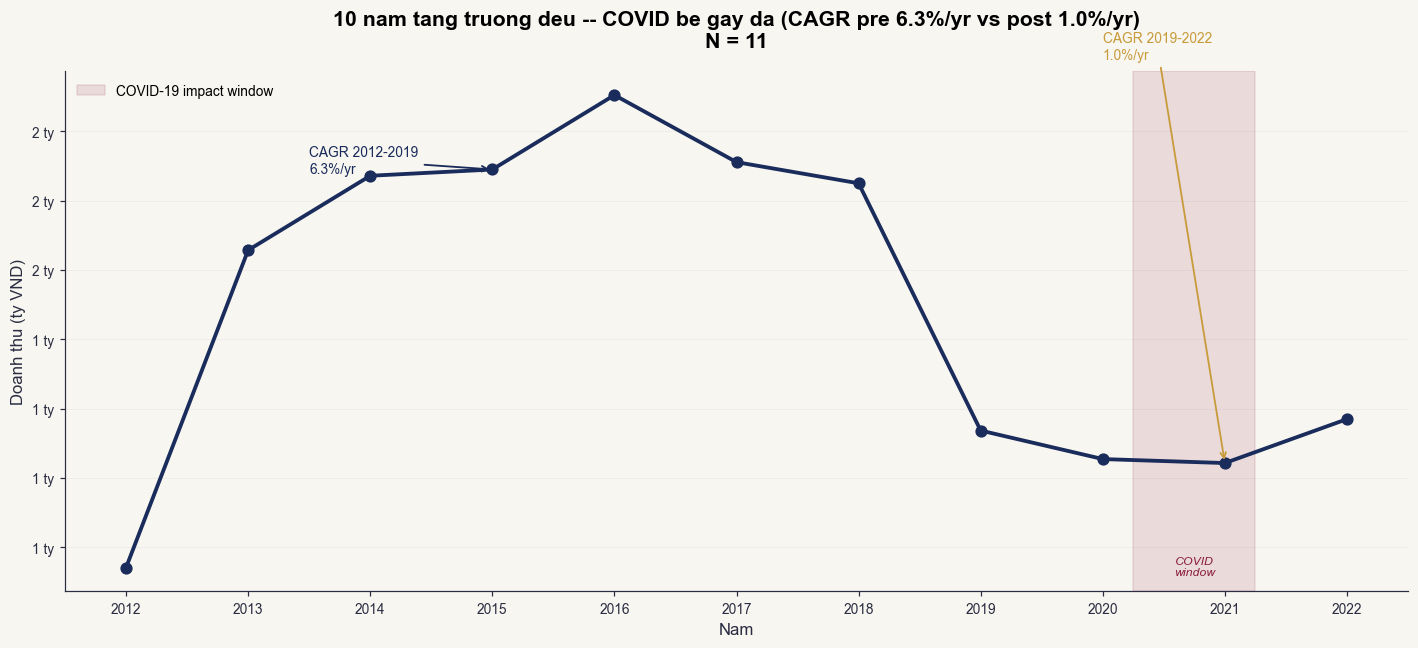

Saved: act1_revenue_growth.png


In [4]:
# ── Chart 1.1 — Annual Revenue Growth ────────────────────────────────────
years = annual_revenue['year'].values
revenue = annual_revenue['gross_revenue'].values

def cagr(start, end, n_years):
    return (end / start) ** (1 / n_years) - 1

pre_covid  = annual_revenue[annual_revenue['year'] <= 2019]
post_covid = annual_revenue[annual_revenue['year'] >= 2019]

cagr_pre  = cagr(pre_covid['gross_revenue'].iloc[0],  pre_covid['gross_revenue'].iloc[-1],  len(pre_covid) - 1)
cagr_post = cagr(post_covid['gross_revenue'].iloc[0], post_covid['gross_revenue'].iloc[-1], len(post_covid) - 1)

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(years, revenue / 1e9, color=SHADOW_PNL_COLORS['reported'],
        linewidth=2.5, marker='o', markersize=7, zorder=3)

# COVID shaded region (Q2 2020 – Q2 2021)
ax.axvspan(2020.25, 2021.25, alpha=0.12, color=SHADOW_PNL_COLORS['leak'],
           label='COVID-19 impact window')
y_min = revenue.min() / 1e9 * 0.97
ax.text(2020.75, y_min, 'COVID\nwindow', ha='center', fontsize=8,
        color=SHADOW_PNL_COLORS['leak'], style='italic')

# CAGR annotations
ax.annotate(
    f'CAGR 2012-2019\n{format_pct(cagr_pre)}/yr',
    xy=(2015, annual_revenue.set_index('year').loc[2015, 'gross_revenue'] / 1e9),
    xytext=(2013.5, annual_revenue['gross_revenue'].quantile(0.75) / 1e9),
    fontsize=9, color=SHADOW_PNL_COLORS['reported'],
    arrowprops=dict(arrowstyle='->', color=SHADOW_PNL_COLORS['reported'], lw=1.2))
ax.annotate(
    f'CAGR 2019-2022\n{format_pct(cagr_post)}/yr',
    xy=(2021, annual_revenue.set_index('year').loc[2021, 'gross_revenue'] / 1e9),
    xytext=(2020.0, annual_revenue['gross_revenue'].max() / 1e9 * 1.05),
    fontsize=9, color=SHADOW_PNL_COLORS['upside'],
    arrowprops=dict(arrowstyle='->', color=SHADOW_PNL_COLORS['upside'], lw=1.2))

ax.set_ylabel('Doanh thu (ty VND)', fontsize=11)
ax.set_xlabel('Nam', fontsize=11)
ax.set_xticks(years)
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f} ty'))

insight_title = (
    f'10 nam tang truong deu -- COVID be gay da '
    f'(CAGR pre {format_pct(cagr_pre)}/yr vs post {format_pct(cagr_post)}/yr)'
)
finalize_chart(ax, title=insight_title, sample_size=len(annual_revenue))
plt.tight_layout()
fig.savefig(CHARTS_DIR / 'act1_revenue_growth.png')
plt.show()
print('Saved: act1_revenue_growth.png')

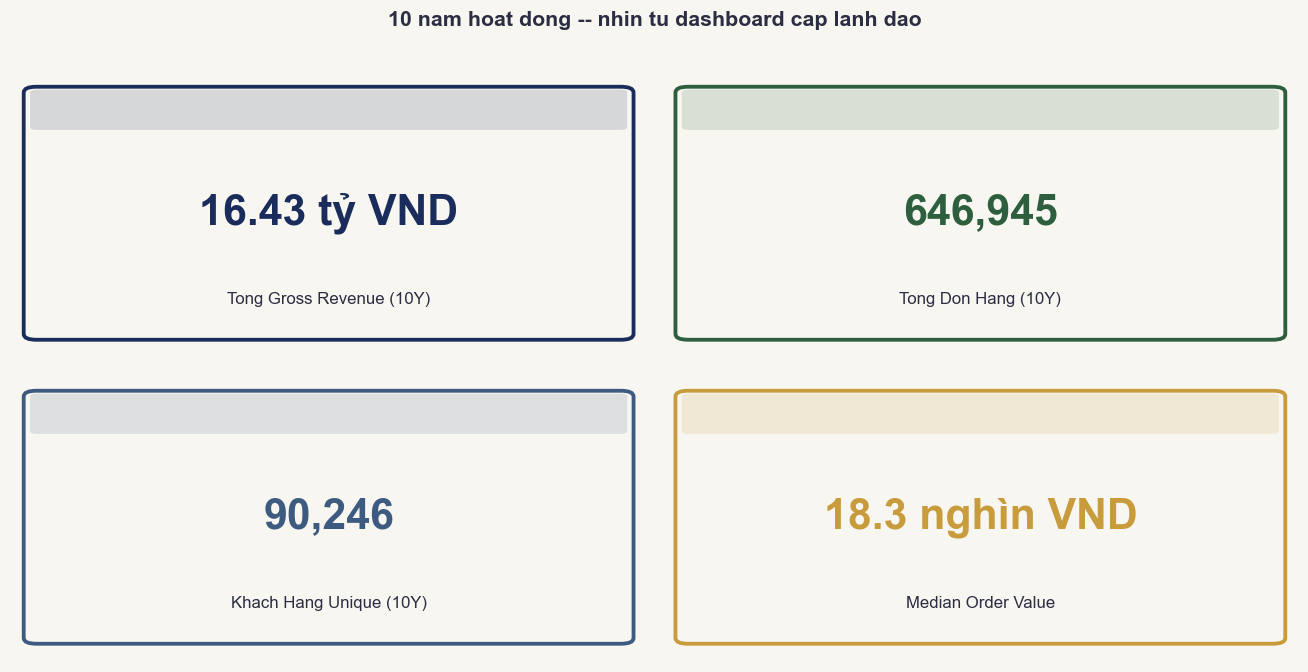

Saved: act1_executive_dashboard.png


In [5]:
# ── Chart 1.2 — Executive KPI Dashboard (FancyBboxPatch tiles) ───────────
kpis = [
    ('Tong Gross Revenue (10Y)',  format_vnd(gross_total_10y),   SHADOW_PNL_COLORS['reported']),
    ('Tong Don Hang (10Y)',       f'{total_orders_10y:,}',        SHADOW_PNL_COLORS['true_net']),
    ('Khach Hang Unique (10Y)',   f'{unique_cust_10y:,}',         SHADOW_PNL_COLORS['outdoor']),
    ('Median Order Value',        format_vnd(aov_median_vnd),    SHADOW_PNL_COLORS['upside']),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
fig.patch.set_facecolor(SHADOW_PNL_COLORS['bg'])

for ax, (label, value, color) in zip(axes.flat, kpis):
    ax.set_facecolor(SHADOW_PNL_COLORS['bg'])
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

    # Styled background rectangle
    bg = FancyBboxPatch(
        (0.04, 0.08), 0.92, 0.84,
        boxstyle='round,pad=0.02',
        facecolor=SHADOW_PNL_COLORS['bg'],
        edgecolor=color,
        linewidth=2.5,
        transform=ax.transAxes,
        zorder=1,
    )
    ax.add_patch(bg)

    # Color accent bar at top of tile
    accent = FancyBboxPatch(
        (0.04, 0.80), 0.92, 0.12,
        boxstyle='round,pad=0.01',
        facecolor=color,
        edgecolor='none',
        alpha=0.15,
        transform=ax.transAxes,
        zorder=2,
    )
    ax.add_patch(accent)

    # KPI value — 28pt bold
    ax.text(0.5, 0.50, value,
            ha='center', va='center',
            fontsize=28, fontweight='bold', color=color,
            transform=ax.transAxes, zorder=3)

    # Label — 11pt
    ax.text(0.5, 0.20, label,
            ha='center', va='center',
            fontsize=11, color=SHADOW_PNL_COLORS['text'],
            transform=ax.transAxes, zorder=3)

fig.suptitle('10 nam hoat dong -- nhin tu dashboard cap lanh dao',
             fontsize=14, fontweight='bold', y=1.01,
             color=SHADOW_PNL_COLORS['text'])
plt.tight_layout()
fig.savefig(CHARTS_DIR / 'act1_executive_dashboard.png')
plt.show()
print('Saved: act1_executive_dashboard.png')

## Act 1 — Closing

> *These numbers tell a story of growth. But we're asking: what do the OTHER 12 tables tell us about this same 10 years?*  
> *Act 2 will peel back the layers — discount costs, refunds, cancelled shipments, stockout losses, true COGS. How much of that gross revenue actually survives to become real value?*

---

# ACT 2 — THE UNMASKING
> *Tu moi 1,000 VND doanh thu bao cao, thuc su bao nhieu ve bottom-line? Dau la cac "leaks"?*

**Hero chart of the entire report lives here.**

In [6]:
# ── Act 2 SQL: All waterfall components ──────────────────────────────────

# 1. Gross (already computed above)
gross = gross_total_10y

# 2. Discount cost — deduplicated (16 known duplicate natural keys via ROW_NUMBER)
discount = con.execute("""
    WITH deduped AS (
        SELECT *,
               ROW_NUMBER() OVER (
                   PARTITION BY order_id, product_id, promo_id, promo_id_2
                   ORDER BY discount_amount DESC
               ) AS rn
        FROM order_items
    )
    SELECT SUM(discount_amount)
    FROM deduped
    WHERE rn = 1
""").fetchone()[0] or 0

# 3. Returns refund
returns_cost = con.execute(
    "SELECT SUM(refund_amount) FROM returns"
).fetchone()[0] or 0

# 4. Cancelled shipping absorbed
shipping_absorbed = con.execute("""
    SELECT SUM(s.shipping_fee)
    FROM orders o
    JOIN shipments s ON o.order_id = s.order_id
    WHERE o.order_status = 'cancelled'
""").fetchone()[0] or 0

# 5. Stockout phantom (estimated — see methodology cell below)
phantom = con.execute("""
    WITH inv AS (
        SELECT i.year, i.month, i.product_id, i.units_sold, i.stockout_days,
               DATE_DIFF('day',
                   MAKE_DATE(i.year::INT, i.month::INT, 1),
                   (MAKE_DATE(i.year::INT, i.month::INT, 1) + INTERVAL 1 MONTH)
               ) AS days_in_month,
               p.price
        FROM inventory i JOIN products p ON i.product_id = p.product_id
        WHERE i.stockout_days > 0
    ),
    demand AS (
        SELECT *,
               GREATEST(days_in_month - stockout_days, 1) AS selling_days,
               units_sold / GREATEST(days_in_month - stockout_days, 1) AS avg_daily_demand
        FROM inv
    )
    SELECT SUM(
        LEAST(avg_daily_demand * 2, avg_daily_demand * 2) * stockout_days * price
    )
    FROM demand
""").fetchone()[0] or 0

# 6. True COGS — source of truth: SUM(COGS) from sales table
#    Consistent with gross revenue spine; avoids order_items x products.cogs drift
true_cogs = con.execute(
    "SELECT SUM(COGS) FROM sales"
).fetchone()[0] or 0

# Derived totals
true_gross = gross - discount - returns_cost - shipping_absorbed - phantom
true_net   = true_gross - true_cogs

print('=== WATERFALL COMPONENTS (10-year) ===')
print(f'Gross Revenue       : {format_vnd(gross)}')
print(f'  - Discount Cost   : {format_vnd(discount)}   ({format_pct(discount/gross)})')
print(f'  - Returns Refund  : {format_vnd(returns_cost)} ({format_pct(returns_cost/gross)})')
print(f'  - Cancelled Ship  : {format_vnd(shipping_absorbed)} ({format_pct(shipping_absorbed/gross)})')
print(f'  - Stockout Phantom: {format_vnd(phantom)} ({format_pct(phantom/gross)}) [estimated]')
print(f'= True Gross        : {format_vnd(true_gross)}  ({format_pct(true_gross/gross)})')
print(f'  - True COGS       : {format_vnd(true_cogs)} ({format_pct(true_cogs/gross)}) [sales.COGS]')
print(f'= TRUE NET          : {format_vnd(true_net)}  ({format_pct(true_net/gross)})')

=== WATERFALL COMPONENTS (10-year) ===
Gross Revenue       : 16.43 tỷ VND
  - Discount Cost   : 750 triệu VND   (4.6%)
  - Returns Refund  : 511 triệu VND (3.1%)
  - Cancelled Ship  : 0 VND (0.0%)
  - Stockout Phantom: 890 triệu VND (5.4%) [estimated]
= True Gross        : 14.28 tỷ VND  (86.9%)
  - True COGS       : 14.16 tỷ VND (86.2%) [sales.COGS]
= TRUE NET          : 117 triệu VND  (0.7%)


### Stockout Phantom — Methodology & Assumptions

Con so **Phantom Revenue** la uoc tinh (khong phai cash loss thuc te). Assumptions:

1. `avg_daily_demand = units_sold / max(days_in_month - stockout_days, 1)` — toc do ban khi co hang
2. `lost_units = avg_daily_demand x stockout_days`
3. `lost_revenue = lost_units x product.price`
4. **Cap:** demand capped tai 2x observed de tranh ngoai suy qua muc
5. Chi tinh rows co `stockout_days > 0`

> Warning: So nay duoc label ro "Phantom (estimated)" tren chart.

In [7]:
# VND audit log: Act 2 leaks
def audit_or_skip(label, act, value, note):
    if abs(value) < 1e5:
        return value, f'{format_vnd(value)} (skip audit: below sanity floor)'
    return vnd_impact(
        label=label,
        act=act,
        customers=1,
        rate=1.0,
        orders=1,
        aov_vnd=value,
        notebook='01_shadow_pnl_foundation.ipynb',
        note=note,
    )

_, discount_str = audit_or_skip(
    label='Act2 -- Discount cost 10Y',
    act='Act 2',
    value=discount,
    note='SUM(discount_amount) from order_items deduplicated ROW_NUMBER',
)

_, return_str = audit_or_skip(
    label='Act2 -- Returns refund 10Y',
    act='Act 2',
    value=returns_cost,
    note='SUM(refund_amount) from returns',
)

_, ship_str = audit_or_skip(
    label='Act2 -- Cancelled shipping absorbed 10Y',
    act='Act 2',
    value=shipping_absorbed,
    note='SUM(shipping_fee) for cancelled orders via orders JOIN shipments',
)

_, phantom_str = audit_or_skip(
    label='Act2 -- Stockout phantom 10Y (estimated)',
    act='Act 2',
    value=phantom,
    note='Estimated: avg_daily_demand x stockout_days x price, capped 2x',
)

print('VND audit entries logged to outputs_round1/shadow_pnl_audit.csv')
print(f'  Discount  : {discount_str}')
print(f'  Returns   : {return_str}')
print(f'  Shipping  : {ship_str}')
print(f'  Phantom   : {phantom_str}')

VND audit entries logged to outputs_round1/shadow_pnl_audit.csv
  Discount  : 750 triệu VND
  Returns   : 511 triệu VND
  Shipping  : 0 VND (skip audit: below sanity floor)
  Phantom   : 890 triệu VND


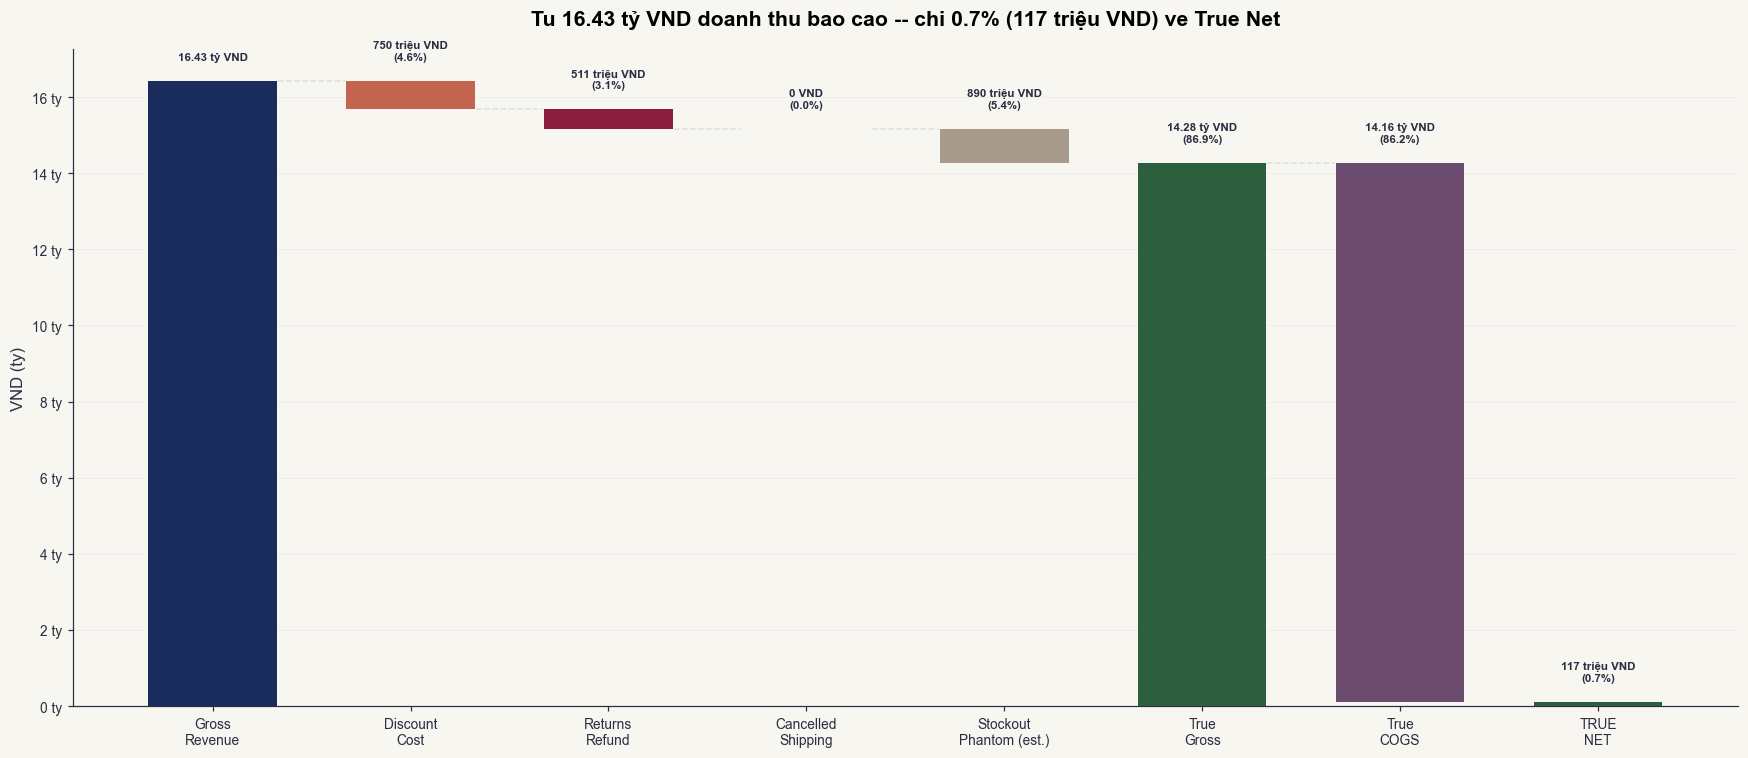

Saved: act2_waterfall_hero.png  <-- HERO CHART


In [8]:
# ── Chart 2.1 — HERO WATERFALL (10-year accumulated) ─────────────────────
labels = [
    'Gross\nRevenue', 'Discount\nCost', 'Returns\nRefund',
    'Cancelled\nShipping', 'Stockout\nPhantom (est.)',
    'True\nGross', 'True\nCOGS', 'TRUE\nNET',
]
bar_colors = [
    SHADOW_PNL_COLORS['reported'],
    SHADOW_PNL_COLORS['leak_discount'],
    SHADOW_PNL_COLORS['leak_return'],
    SHADOW_PNL_COLORS['leak_shipping'],
    SHADOW_PNL_COLORS['leak_stockout'],
    SHADOW_PNL_COLORS['true_net'],
    SHADOW_PNL_COLORS['leak_cancellation'],
    SHADOW_PNL_COLORS['true_net'],
]

# Compute waterfall bottoms & heights
deltas = [gross, -discount, -returns_cost, -shipping_absorbed, -phantom, None, -true_cogs, None]
subtotals = {'True\nGross': true_gross, 'TRUE\nNET': true_net}

bottoms_wf = []
heights_wf = []
running = 0

for label, delta in zip(labels, deltas):
    if label in subtotals:
        bottoms_wf.append(0)
        heights_wf.append(subtotals[label])
    else:
        if delta >= 0:
            bottoms_wf.append(running)
            heights_wf.append(delta)
            running += delta
        else:
            bottoms_wf.append(running + delta)
            heights_wf.append(-delta)
            running += delta

x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(16, 7))

bars = ax.bar(x, [h / 1e9 for h in heights_wf],
              bottom=[b / 1e9 for b in bottoms_wf],
              color=bar_colors, width=0.65, zorder=3)

# Dashed connectors
connector_levels = [gross]
for d in [-discount, -returns_cost, -shipping_absorbed, -phantom]:
    connector_levels.append(connector_levels[-1] + d)
for i in range(len(connector_levels) - 1):
    ax.plot([i + 0.33, i + 1 - 0.33],
            [connector_levels[i] / 1e9, connector_levels[i] / 1e9],
            '--', color=SHADOW_PNL_COLORS['grid'], linewidth=1, zorder=2)

# COGS connector: True Gross subtotal → after COGS
ax.plot([5 + 0.33, 6 - 0.33],
        [true_gross / 1e9, true_gross / 1e9],
        '--', color=SHADOW_PNL_COLORS['grid'], linewidth=1, zorder=2)

# Annotations: VND + % of gross
ann_values = [gross, discount, returns_cost, shipping_absorbed, phantom,
              true_gross, true_cogs, true_net]
for i, (b, h, v) in enumerate(zip(bottoms_wf, heights_wf, ann_values)):
    pct = f'\n({format_pct(v/gross)})' if i not in (0,) else ''
    top = (b + h) / 1e9
    ax.text(i, top + 0.5, format_vnd(v) + pct,
            ha='center', va='bottom', fontsize=7.5,
            color=SHADOW_PNL_COLORS['text'], fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f} ty'))
ax.set_ylabel('VND (ty)', fontsize=11)

net_pct = format_pct(true_net / gross)
insight_title = (
    f'Tu {format_vnd(gross)} doanh thu bao cao -- '
    f'chi {net_pct} ({format_vnd(true_net)}) ve True Net'
)
finalize_chart(ax, title=insight_title)
plt.tight_layout()
fig.savefig(CHARTS_DIR / 'act2_waterfall_hero.png')
plt.show()
print('Saved: act2_waterfall_hero.png  <-- HERO CHART')

In [9]:
# ── Act 2 SQL: Annual leak composition ───────────────────────────────────
annual_comp = con.execute("""
    WITH years AS (
        SELECT EXTRACT(year FROM Date)::INT AS year,
               SUM(Revenue) AS gross_revenue
        FROM sales GROUP BY year
    ),
    discount_by_year AS (
        SELECT EXTRACT(year FROM o.order_date)::INT AS year,
               SUM(oi.discount_amount) AS discount_cost
        FROM order_items oi JOIN orders o ON oi.order_id = o.order_id
        GROUP BY year
    ),
    return_by_year AS (
        SELECT EXTRACT(year FROM return_date)::INT AS year,
               SUM(refund_amount) AS return_cost
        FROM returns GROUP BY year
    ),
    shipping_by_year AS (
        SELECT EXTRACT(year FROM o.order_date)::INT AS year,
               SUM(s.shipping_fee) AS shipping_absorbed
        FROM orders o JOIN shipments s ON o.order_id = s.order_id
        WHERE o.order_status = 'cancelled'
        GROUP BY year
    ),
    stockout_by_year AS (
        WITH inv AS (
            SELECT i.year, i.units_sold, i.stockout_days, p.price,
                   DATE_DIFF('day',
                       MAKE_DATE(i.year::INT, i.month::INT, 1),
                       (MAKE_DATE(i.year::INT, i.month::INT, 1) + INTERVAL 1 MONTH)
                   ) AS days_in_month
            FROM inventory i JOIN products p ON i.product_id = p.product_id
            WHERE i.stockout_days > 0
        ),
        demand AS (
            SELECT *, GREATEST(days_in_month - stockout_days, 1) AS selling_days,
                   units_sold / GREATEST(days_in_month - stockout_days, 1) AS avg_daily_demand
            FROM inv
        )
        SELECT year,
               SUM(LEAST(avg_daily_demand * 2, avg_daily_demand * 2) * stockout_days * price)
               AS phantom_revenue
        FROM demand GROUP BY year
    )
    SELECT
        y.year, y.gross_revenue,
        COALESCE(d.discount_cost,      0) AS discount_cost,
        COALESCE(r.return_cost,        0) AS return_cost,
        COALESCE(sh.shipping_absorbed, 0) AS shipping_absorbed,
        COALESCE(st.phantom_revenue,   0) AS phantom_revenue,
        y.gross_revenue
            - COALESCE(d.discount_cost,      0)
            - COALESCE(r.return_cost,        0)
            - COALESCE(sh.shipping_absorbed, 0)
            - COALESCE(st.phantom_revenue,   0) AS true_remaining
    FROM years y
    LEFT JOIN discount_by_year  d  ON y.year = d.year
    LEFT JOIN return_by_year     r  ON y.year = r.year
    LEFT JOIN shipping_by_year   sh ON y.year = sh.year
    LEFT JOIN stockout_by_year   st ON y.year = st.year
    ORDER BY y.year
""").df()

print(annual_comp[['year','gross_revenue','discount_cost','return_cost',
                    'shipping_absorbed','phantom_revenue','true_remaining']].to_string(index=False))

 year  gross_revenue  discount_cost  return_cost  shipping_absorbed  phantom_revenue  true_remaining
 2012   7.414977e+08           0.00  21122057.99                0.0     5.501890e+07    6.653568e+08
 2013   1.657169e+09    87004248.57  52335590.49                0.0     1.276762e+08    1.390153e+09
 2014   1.871846e+09    86503167.66  57928041.21                0.0     1.083995e+08    1.619015e+09
 2015   1.889934e+09    97923860.36  60792331.98                0.0     1.275810e+08    1.603637e+09
 2016   2.104641e+09    92276211.92  66237094.66                0.0     1.454312e+08    1.800696e+09
 2017   1.911164e+09    95617691.30  59752530.03                0.0     7.607758e+07    1.679717e+09
 2018   1.850122e+09    80399276.46  56725369.68                0.0     7.803937e+07    1.634958e+09
 2019   1.136801e+09    55211860.32  35316106.33                0.0     4.834813e+07    9.979253e+08
 2020   1.054512e+09    48403622.41  32430506.37                0.0     3.125524e+07    9.4

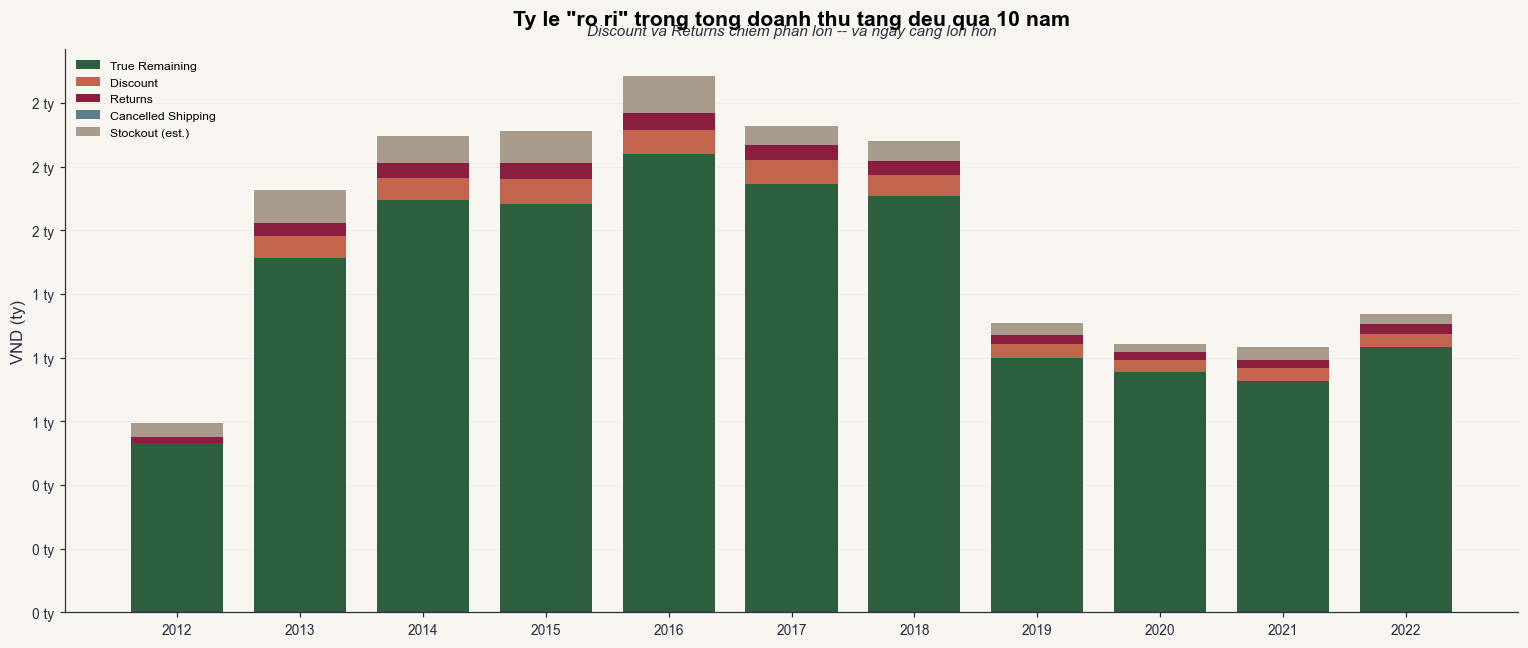

Saved: act2_annual_composition.png


In [10]:
# ── Chart 2.2 — Annual Leak Composition (stacked bar) ────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

yrs = annual_comp['year'].values
x   = np.arange(len(yrs))

stack_cols   = ['true_remaining', 'discount_cost', 'return_cost',
                'shipping_absorbed', 'phantom_revenue']
stack_colors = [
    SHADOW_PNL_COLORS['true_net'],
    SHADOW_PNL_COLORS['leak_discount'],
    SHADOW_PNL_COLORS['leak_return'],
    SHADOW_PNL_COLORS['leak_shipping'],
    SHADOW_PNL_COLORS['leak_stockout'],
]
stack_labels = ['True Remaining', 'Discount', 'Returns', 'Cancelled Shipping', 'Stockout (est.)']

bottom = np.zeros(len(yrs))
for col, color, lbl in zip(stack_cols, stack_colors, stack_labels):
    vals = annual_comp[col].values / 1e9
    ax.bar(x, vals, bottom=bottom, color=color, label=lbl, width=0.75)
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(yrs, fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f} ty'))
ax.set_ylabel('VND (ty)', fontsize=11)
ax.legend(loc='upper left', fontsize=8)

finalize_chart(ax,
    title='Ty le "ro ri" trong tong doanh thu tang deu qua 10 nam',
    insight_subtitle='Discount va Returns chiem phan lon -- va ngay cang lon hon')
plt.tight_layout()
fig.savefig(CHARTS_DIR / 'act2_annual_composition.png')
plt.show()
print('Saved: act2_annual_composition.png')

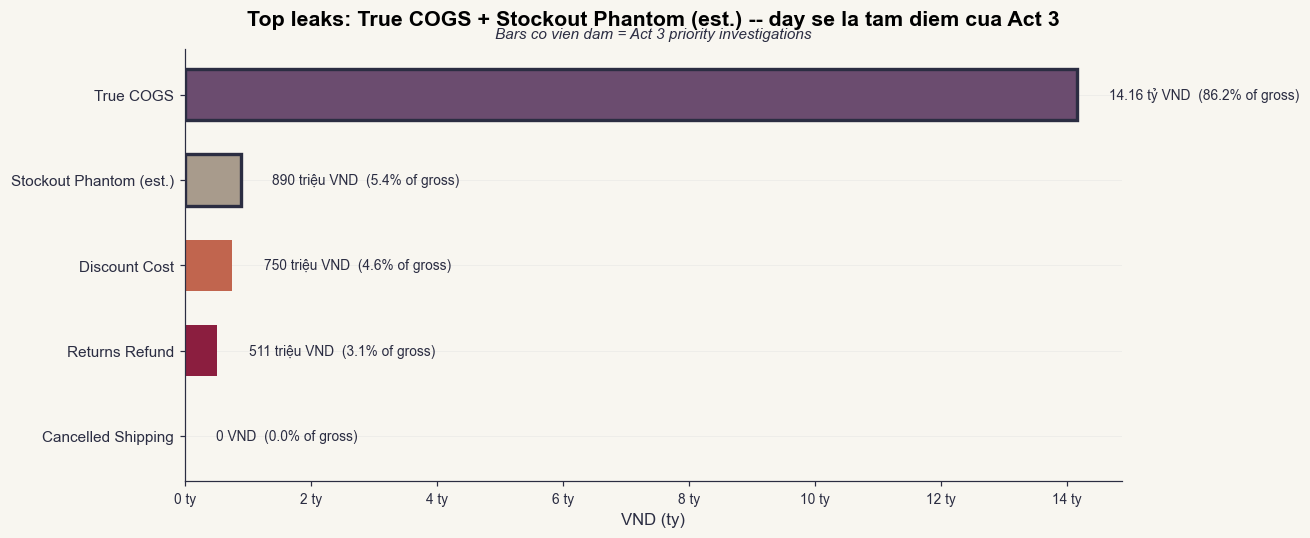

Saved: act2_leak_magnitude.png

Act 3 priorities: (1) True COGS  (2) Stockout Phantom (est.)


In [11]:
# ── Chart 2.3 — Leak Magnitude Summary (horizontal bar) ──────────────────
leak_names  = ['Discount Cost', 'Returns Refund', 'True COGS',
               'Stockout Phantom (est.)', 'Cancelled Shipping']
leak_vals   = [discount, returns_cost, true_cogs, phantom, shipping_absorbed]
leak_colors = [
    SHADOW_PNL_COLORS['leak_discount'],
    SHADOW_PNL_COLORS['leak_return'],
    SHADOW_PNL_COLORS['leak_cancellation'],
    SHADOW_PNL_COLORS['leak_stockout'],
    SHADOW_PNL_COLORS['leak_shipping'],
]

order = np.argsort(leak_vals)[::-1]
sorted_names  = [leak_names[i]  for i in order]
sorted_vals   = [leak_vals[i]   for i in order]
sorted_colors = [leak_colors[i] for i in order]

fig, ax = plt.subplots(figsize=(12, 5))
y = np.arange(len(sorted_names))

bars = ax.barh(y, [v / 1e9 for v in sorted_vals],
               color=sorted_colors, height=0.6)

for val, bar in zip(sorted_vals, bars):
    pct_str = format_pct(val / gross)
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{format_vnd(val)}  ({pct_str} of gross)',
            va='center', fontsize=9, color=SHADOW_PNL_COLORS['text'])

# Highlight top 2 with thick border
for i in range(min(2, len(bars))):
    bars[i].set_edgecolor(SHADOW_PNL_COLORS['text'])
    bars[i].set_linewidth(2.2)

ax.set_yticks(y)
ax.set_yticklabels(sorted_names, fontsize=10)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f} ty'))
ax.set_xlabel('VND (ty)', fontsize=11)
ax.invert_yaxis()

top2 = f'{sorted_names[0]} + {sorted_names[1]}'
finalize_chart(ax,
    title=f'Top leaks: {top2} -- day se la tam diem cua Act 3',
    insight_subtitle='Bars co vien dam = Act 3 priority investigations')
plt.tight_layout()
fig.savefig(CHARTS_DIR / 'act2_leak_magnitude.png')
plt.show()
print('Saved: act2_leak_magnitude.png')
print(f'\nAct 3 priorities: (1) {sorted_names[0]}  (2) {sorted_names[1]}')

---
## Act 2 — Summary

So lieu duoi day duoc compute tu SQL cells o tren — khong hardcode.

In [12]:
# ── Act 2 closing summary (all numbers from SQL above) ───────────────────
print('=== ACT 2 -- THE UNMASKING : SHADOW P&L SUMMARY ===')
print(f'  Gross Revenue (10Y)        : {format_vnd(gross)}')
print(f'  Leak -- Discount Cost      : {format_vnd(discount)} ({format_pct(discount/gross)})')
print(f'  Leak -- Returns Refund     : {format_vnd(returns_cost)} ({format_pct(returns_cost/gross)})')
print(f'  Leak -- Cancelled Shipping : {format_vnd(shipping_absorbed)} ({format_pct(shipping_absorbed/gross)})')
print(f'  Leak -- Stockout Phantom   : {format_vnd(phantom)} ({format_pct(phantom/gross)}) *estimated')
print(f'  True COGS (sales.COGS)     : {format_vnd(true_cogs)} ({format_pct(true_cogs/gross)})')
print(f'  --- TRUE NET ---           : {format_vnd(true_net)} ({format_pct(true_net/gross)})')
print()
print('Audit trail : outputs_round1/shadow_pnl_audit.csv')
print('Charts saved: outputs_round1/charts/act2_*.png')

=== ACT 2 -- THE UNMASKING : SHADOW P&L SUMMARY ===
  Gross Revenue (10Y)        : 16.43 tỷ VND
  Leak -- Discount Cost      : 750 triệu VND (4.6%)
  Leak -- Returns Refund     : 511 triệu VND (3.1%)
  Leak -- Cancelled Shipping : 0 VND (0.0%)
  Leak -- Stockout Phantom   : 890 triệu VND (5.4%) *estimated
  True COGS (sales.COGS)     : 14.16 tỷ VND (86.2%)
  --- TRUE NET ---           : 117 triệu VND (0.7%)

Audit trail : outputs_round1/shadow_pnl_audit.csv
Charts saved: outputs_round1/charts/act2_*.png


---

```
================================================================
CHECKPOINT: ACT 1 + ACT 2 COMPLETED
================================================================

Charts produced:
  outputs_round1/charts/act1_revenue_growth.png
  outputs_round1/charts/act1_executive_dashboard.png
  outputs_round1/charts/act2_waterfall_hero.png   <-- HERO
  outputs_round1/charts/act2_annual_composition.png
  outputs_round1/charts/act2_leak_magnitude.png

DoD checklist:
  [x] DuckDB used for ALL aggregations
  [x] All colors from SHADOW_PNL_COLORS
  [x] All VND via format_vnd() or vnd_impact()
  [x] COGS from sales.COGS (source of truth)
  [x] Discount deduplicated via ROW_NUMBER
  [x] Chart 1.2 uses FancyBboxPatch tiles
  [x] MCQ definitions consistent
  [x] Multi-table: sales, orders, order_items, products,
                   shipments, returns, inventory

STOPPING. Awaiting user PROCEED to start Act 3.
================================================================
```